In [80]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

import logging 
logging.getLogger().setLevel(logging.INFO)

In [81]:
# Frequency object
f1          = 0.01
nfreq       = 100
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_39"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.42], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_39 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


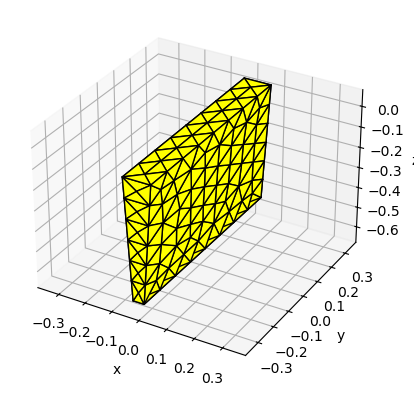

In [82]:
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [0, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin\

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)

#axis = cpt.Axis(vector=(0, 1, 0), point=(0, 0, -flapDraft))
#flap1.add_rotation_dof(name="Pitch_about_hinge", axis=axis)
#flap1.rotation_center = (0, 0, -flapDraft)

# try specifying cg at hinge so Capytaine calculates hydrostatics around hinge
flap1.center_of_mass = flap1CG
flap1.rotation_center = (0, 0, -flapDraft)
flap1.add_rotation_dof(name='Pitch')

flap_mass = 23.1
flap_inertia_cg = 1.19
flap_inertia_hinge = flap_inertia_cg + flap_mass*cgHeightAboveHinge**2
flap1.mass = flap_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia_hinge]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

flap1.show_matplotlib()
#flap1.show()

In [83]:
# run BEM calculations
bem_data_file = 'foswec_1_flap_WOT_100freqs.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(flap1, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

INFO:capytaine.green_functions.delhommeau:Loading tabulation from C:\Users\jtgrasb\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_372_-251.0_1001.npz


[16:23:53] WARNING  center_of_mass already defined as [0, 0, -0.41999999999999993].

           WARNING  rotation_center already defined as (0, 0, -0.59).

INFO:capytaine.bodies.bodies:Clipping copy_of_flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_39 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


Output()

...

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.095, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.158, water_depth=2.0, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.158, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.220, water_depth=2.0, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.220, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.283, water_depth=2.0, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.283, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).


INFO:capytaine.bem.solver:Solver timer summary:
                      total  nb_calls      mean
task                                           
Solve total       12.110258       200  0.060551
  Green function   9.507131       200  0.047536
  Linear solver    1.587216       192  0.008267


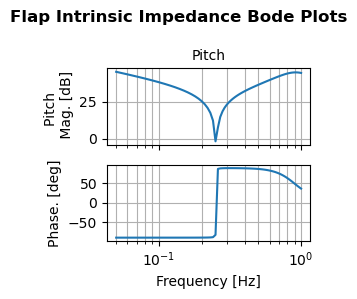

In [84]:
hd = wot.add_linear_friction(bem_data, friction = None) 
hd = wot.check_radiation_damping(hd)

intrinsic_impedance = wot.hydrodynamic_impedance(hd)
fig, axes = wot.utilities.plot_bode_impedance(intrinsic_impedance,
                                              'Flap Intrinsic Impedance')

bem_data = bem_data.fillna(0)

In [85]:
print(hd['inertia_matrix'])

<xarray.DataArray 'inertia_matrix' (influenced_dof: 1, radiating_dof: 1)> Size: 8B
array([[1.85759]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 20B 'Pitch'
  * radiating_dof   (radiating_dof) <U5 20B 'Pitch'
    g               float64 8B 9.81
    rho             float64 8B 1.025e+03
    body_name       <U22 88B 'copy_of_flap1_immersed'
    water_depth     float64 8B 2.0
    forward_speed   float64 8B 0.0


In [ ]:
# prep bem data
hd = wot.add_linear_friction(bem_data, friction = 24) 
#we're not actually adding friction, but need the datavariables in hd 
hd = wot.check_radiation_damping(hd)
hd.hydrostatic_stiffness[:] = 87
intrinsic_impedance = wot.hydrodynamic_impedance(hd)

f_vec_bem = freq
mag_bem = 20.0 * np.log10(np.abs(intrinsic_impedance.squeeze()))
phase_bem = ((np.rad2deg(np.unwrap(np.angle(intrinsic_impedance.squeeze()))) + 180) % 360) - 180

# prep experimental data 
impedance_data = loadmat('validation_data/ZiData.mat')

varName = 'ResponseData'

f_vec_exp = impedance_data['impedance']['Frequency'].squeeze()/(2*np.pi)
mag_exp_aft = 20.0 * np.log10(np.abs(impedance_data['impedance'][varName][0,0][0,0,:].squeeze()))
mag_exp_aftbow = 20.0 * np.log10(np.abs(impedance_data['impedance'][varName][0,0][0,1,:].squeeze()))
mag_exp_bow = 20.0 * np.log10(np.abs(impedance_data['impedance'][varName][0,0][1,1,:].squeeze()))
mag_exp_bowaft = 20.0 * np.log10(np.abs(impedance_data['impedance'][varName][0,0][1,0,:].squeeze()))
phase_exp_aft = np.angle(impedance_data['impedance'][varName][0,0][0,0,:].squeeze())*180/np.pi
phase_exp_aftbow = np.angle(impedance_data['impedance'][varName][0,0][0,1,:].squeeze())*180/np.pi
phase_exp_bow = np.angle(impedance_data['impedance'][varName][0,0][1,1,:].squeeze())*180/np.pi
phase_exp_bowaft = np.angle(impedance_data['impedance'][varName][0,0][1,0,:].squeeze())*180/np.pi

[16:39:13] WARNING  Linear damping for DOF "Pitch" has negative or close to zero terms. Shifting up damping terms  
                    [0 1 2 3] to a minimum of 1e-06 N/(m/s)

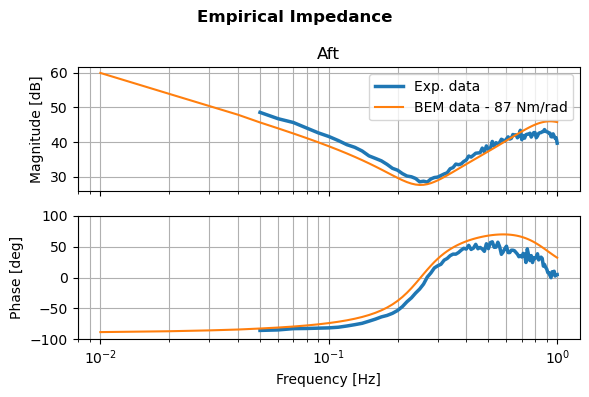

In [103]:

fig, axes = plt.subplots(2, 1,tight_layout=True, sharex=True, figsize=(6, 4), squeeze=False)
fig.suptitle('Empirical Impedance', fontweight='bold')

axes[0,0].semilogx(f_vec_exp.squeeze(), mag_exp_aft, label='Exp. data',lw=2.5) 
axes[1,0].semilogx(f_vec_exp, phase_exp_aft,lw=2.5) 
axes[0,0].semilogx(f_vec_bem.squeeze(), mag_bem, label=f'BEM data - 87 Nm/rad')  
axes[1,0].semilogx(f_vec_bem, phase_bem) 
axes[0,0].set_title('Aft')
axes[1,0].set_ylim([-100,100])
axes[0,0].grid(True, which = 'both')
axes[1,0].grid(True, which = 'both')
axes[1,0].set_xlabel(f'Frequency [Hz]', fontsize=10)
axes[0,0].set_ylabel(f'Magnitude [dB]', fontsize=10)
axes[1,0].set_ylabel(f'Phase [deg]', fontsize=10)

axes[0,0].legend()

#fig.savefig('../figs/impedanceValidation.pdf', bbox_inches='tight')